# 📦 Pharmacy Demand Prediction — Clean Pipeline
> Leakage-free • Time-aware split • Log-transformed target

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, r2_score, mean_absolute_percentage_error


## 2. Load & Basic Cleaning

In [2]:
FILE_PATH = 'updated16_file.csv'
df = pd.read_csv(FILE_PATH)
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')

# Parse dates — coerce bad values (e.g. '0000-00-00') to NaT then drop
df['date'] = pd.to_datetime(df['creation_date'], errors='coerce')
before = len(df)
df = df.dropna(subset=['date']).copy()
print(f'Dropped {before - len(df)} rows with invalid dates. Remaining: {len(df)}')

# Ensure numeric targets
df['quantity']     = pd.to_numeric(df['quantity'],     errors='coerce').fillna(0)
df['total_amount'] = pd.to_numeric(df['total_amount'], errors='coerce').fillna(0)

df.head(3)


Shape: (10000, 22)
Columns: ['id', 'supplier_id', 'invoice_id', 'prod_id', 'product_name', 'quantity', 'discount', 'total_amount', 'account_id', 'account_name', 'account_address', 'user_id', 'user_name', 'employee_name', 'city', 'region', 'area', 'area_id', 'creation_date', 'created_at', 'branch_code', 'Global_Account_ID']
Dropped 10 rows with invalid dates. Remaining: 9990


,id,supplier_id,invoice_id,prod_id,product_name,quantity,discount,total_amount,account_id,account_name,...,employee_name,city,region,area,area_id,creation_date,created_at,branch_code,Global_Account_ID,date
0,48652728,59,32259,7,سيبروسين مرهم س ج,10,15.0,178.50,637,صيدليه مها مديريه امن الجيزه ش,...,نهى الدالى,الجيزة,القاهرة الكبرى,الجيزة,17.0,2025-05-25 13:43:10,2026-05-19 16:29:03,3.0,GLB_0001,2025-05-25 13:43:10
1,48652935,59,32281,7,سيبروسين مرهم س ج,3,15.0,53.55,4365,صيدليه السعدني فيصل,...,نهى الدالى,الجيزة,القاهرة الكبرى,فيصل,99.0,2025-05-25 14:35:04,2026-05-19 16:29:03,2.0,GLB_0002,2025-05-25 14:35:04
2,48653089,59,32301,7,سيبروسين مرهم س ج,2,21.0,33.18,3297,صيدليه مني احمد امبابه,...,اسماء رجب,الجيزة,القاهرة الكبرى,إمبابة,9.0,2025-05-25 15:21:21,2026-05-19 16:29:03,4.0,GLB_0003,2025-05-25 15:21:21


## 3. Temporal Feature Engineering

In [3]:
df['month']       = df['date'].dt.month
df['week']        = df['date'].dt.isocalendar().week.astype(int)
df['day']         = df['date'].dt.day
df['day_of_week'] = df['date'].dt.dayofweek

# Friday = 4 is the Egyptian weekend
df['is_weekend']          = df['date'].dt.dayofweek.isin([4]).astype(int)
df['is_holiday_or_weekend'] = df['date'].dt.dayofweek.isin([4, 5]).astype(int)

def get_season(month):
    if month in [12, 1, 2]:  return 'Winter'
    elif month in [3, 4, 5]: return 'Spring'
    elif month in [6, 7, 8]: return 'Summer'
    else:                     return 'Autumn'

df['season'] = df['month'].apply(get_season)
print(df[['date', 'day', 'week', 'month', 'season', 'is_weekend']].head())


                 date  day  week  month  season  is_weekend
0 2025-05-25 13:43:10   25    21      5  Spring           0
1 2025-05-25 14:35:04   25    21      5  Spring           0
2 2025-05-25 15:21:21   25    21      5  Spring           0
3 2025-05-25 20:49:54   25    21      5  Spring           0
4 2026-04-12 13:51:32   12    15      4  Spring           0


## 4. Chronological Train / Test Split
> **Critical:** split by time before computing any aggregates or lags — this is what prevents data leakage.

In [4]:
df = df.sort_values('date').reset_index(drop=True)

split_idx  = int(len(df) * 0.8)
split_date = df.loc[split_idx, 'date']
print(f'Train: up to {split_date.date()}  |  Test: after {split_date.date()}')

train_df = df.iloc[:split_idx].copy()
test_df  = df.iloc[split_idx:].copy()
print(f'Train rows: {len(train_df):,}  |  Test rows: {len(test_df):,}')


Train: up to 2026-02-04  |  Test: after 2026-02-04
Train rows: 7,992  |  Test rows: 1,998


## 5. Pharmacy-Level Aggregates (computed on train only, merged into test)

In [5]:
# Compute on TRAIN only
monetary  = train_df.groupby('account_id')['total_amount'].mean().rename('avg_invoice_value')
diversity = train_df.groupby('account_id')['prod_id'].nunique().rename('product_diversity')
avg_qty   = train_df.groupby('account_id')['quantity'].mean().rename('avg_quantity_per_account')

pharmacy_stats = pd.concat([monetary, diversity, avg_qty], axis=1).reset_index()

# Merge into both splits — test gets train-era stats (no leakage)
train_df = train_df.merge(pharmacy_stats, on='account_id', how='left')
test_df  = test_df.merge(pharmacy_stats,  on='account_id', how='left')

# Fill pharmacies in test that never appeared in train with train medians
for col in ['avg_invoice_value', 'product_diversity', 'avg_quantity_per_account']:
    median_val = train_df[col].median()
    test_df[col].fillna(median_val, inplace=True)
    train_df[col].fillna(median_val, inplace=True)

print('Pharmacy aggregates merged. Sample:')
print(train_df[['account_id', 'avg_invoice_value', 'product_diversity', 'avg_quantity_per_account']].head())


Pharmacy aggregates merged. Sample:
   account_id  avg_invoice_value  product_diversity  avg_quantity_per_account
0        4595         248.482857                  7                  8.714286
1        4595         248.482857                  7                  8.714286
2        4595         248.482857                  7                  8.714286
3        4595         248.482857                  7                  8.714286
4        4595         248.482857                  7                  8.714286


## 6. Lag Features & Unit Price
> Sort by product + date, then shift within each product group.

In [6]:
def build_lag_features(df_part):
    df_part = df_part.sort_values(['prod_id', 'date'])
    df_part['quantity_lag_1'] = df_part.groupby('prod_id')['quantity'].shift(1).fillna(0)
    df_part['quantity_lag_2'] = df_part.groupby('prod_id')['quantity'].shift(2).fillna(0)
    df_part['unit_price']     = (df_part['total_amount']
                                  / df_part['quantity'].replace(0, np.nan)).fillna(0)
    return df_part

# Build lags separately inside each split
train_df = build_lag_features(train_df)
test_df  = build_lag_features(test_df)

print('Lag features built. Sample:')
print(train_df[['prod_id', 'date', 'quantity', 'quantity_lag_1', 'quantity_lag_2']].head(8))


Lag features built. Sample:
      prod_id                date  quantity  quantity_lag_1  quantity_lag_2
991         1 2024-11-20 03:10:00         1             0.0             0.0
992         1 2024-11-20 03:50:56         1             1.0             0.0
993         1 2024-11-20 15:29:03         1             1.0             1.0
1000        1 2024-11-20 16:35:55         1             1.0             1.0
1001        1 2024-11-20 17:08:05         3             1.0             1.0
1002        1 2024-11-20 22:41:27         1             3.0             1.0
1005        1 2024-11-21 07:55:49         2             1.0             3.0
3207        1 2025-08-05 02:21:57         2             2.0             1.0


## 7. Days Since Last Order (leakage-free)
> Use inter-row date diff per pharmacy, not `Timestamp.now()`.

In [7]:
def add_days_since_last(df_part):
    df_part = df_part.sort_values(['account_id', 'date'])
    df_part['days_since_last_order'] = (
        df_part.groupby('account_id')['date'].diff().dt.days.fillna(0)
    )
    return df_part

train_df = add_days_since_last(train_df)
test_df  = add_days_since_last(test_df)

print(train_df[['account_id', 'date', 'days_since_last_order']].head(8))


      account_id                date  days_since_last_order
5135           1 2025-11-19 14:17:47                    0.0
5137           1 2025-11-19 14:17:47                    0.0
5138           1 2025-11-19 14:17:47                    0.0
5136           1 2025-11-19 14:17:47                    0.0
6424         141 2025-12-31 12:07:54                    0.0
6423         141 2025-12-31 12:07:54                    0.0
5289         143 2025-11-29 16:17:37                    0.0
5290         143 2025-11-29 16:17:37                    0.0


## 8. Assemble Features & Target

In [13]:
FEATURES = [
    'avg_invoice_value', 'product_diversity', 'days_since_last_order',
    'is_weekend', 'month', 'day', 'avg_quantity_per_account',
    'quantity_lag_1', 'quantity_lag_2', 'unit_price',
    'supplier_id', 'discount', 'season','area_id','area','region','city','employee_name','total_amount','account_name','account_id'
]

def prep(df_part, fit_columns=None):
    X = pd.get_dummies(df_part[FEATURES], drop_first=True)
    if fit_columns is not None:
        X = X.reindex(columns=fit_columns, fill_value=0)
    return X

X_train = prep(train_df)
X_test  = prep(test_df, fit_columns=X_train.columns)

# Log-transform target to handle extreme skew (max=1354, mean~4.5)
y_train     = train_df['quantity']
y_test      = test_df['quantity']
y_train_log = np.log1p(y_train)

print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')
print(f'y_train log-scale stats: mean={y_train_log.mean():.2f}, std={y_train_log.std():.2f}')


X_train: (7992, 1178)  |  X_test: (1998, 1178)
y_train log-scale stats: mean=1.25, std=0.62


## 9. Train — Random Forest with Hyperparameter Tuning

In [14]:
rf = RandomForestRegressor(random_state=42)
params = {
    'n_estimators': [100, 200, 300],
    'max_depth':    [10, 20, None],
    'min_samples_leaf': [1, 3, 5]
}

rf_search = RandomizedSearchCV(
    rf, params, cv=3, n_iter=6, scoring='r2',
    n_jobs=-1, random_state=42
)
rf_search.fit(X_train, y_train_log)

best_model = rf_search.best_estimator_
print(f'Best params: {rf_search.best_params_}')


Best params: {'n_estimators': 200, 'min_samples_leaf': 3, 'max_depth': 20}


## 10. Evaluation

In [15]:
log_preds  = best_model.predict(X_test)
preds      = np.expm1(log_preds)          # back to original scale
preds      = np.maximum(preds, 0)         # no negative quantities

mae  = mean_absolute_error(y_test, preds)
r2   = r2_score(y_test, preds)
mape = mean_absolute_percentage_error(y_test[y_test > 0], preds[y_test > 0])

# Naive baseline: predict each product's mean quantity from train
prod_mean  = train_df.groupby('prod_id')['quantity'].mean()
naive_pred = test_df['prod_id'].map(prod_mean).fillna(train_df['quantity'].mean())
naive_mae  = mean_absolute_error(y_test, naive_pred)

print('=' * 45)
print(f'  MAE  (model)   : {mae:.4f}')
print(f'  MAE  (naive)   : {naive_mae:.4f}  <- baseline')
print(f'  R²   (model)   : {r2:.4f}')
print(f'  MAPE (model)   : {mape*100:.2f}%')
print('=' * 45)
if mae < naive_mae:
    print(f'  ✅ Model beats naive by {naive_mae - mae:.2f} units MAE')
else:
    print('  ⚠️  Model does NOT beat naive baseline — consider more features or data.')


  MAE  (model)   : 1.0247
  MAE  (naive)   : 3.9798  <- baseline
  R²   (model)   : 0.7124
  MAPE (model)   : 2.96%
  ✅ Model beats naive by 2.96 units MAE


## 12. Actual vs Predicted (sample)

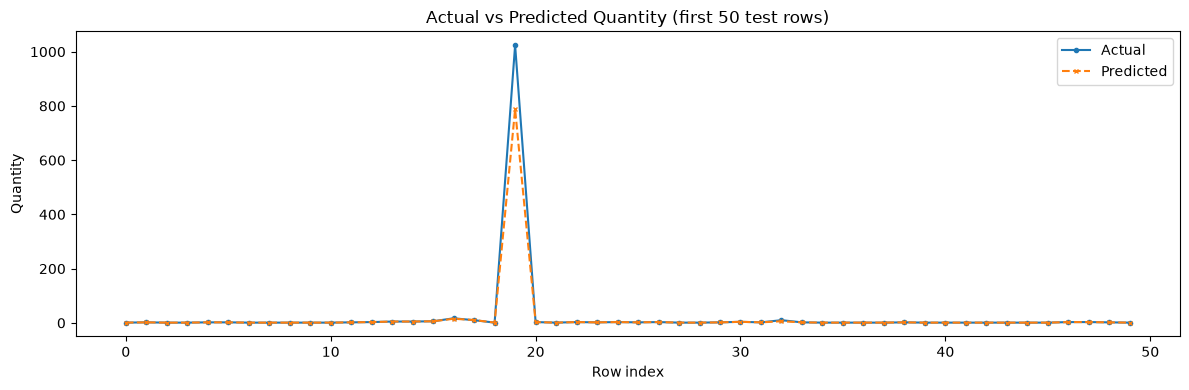

In [17]:
sample = pd.DataFrame({'Actual': y_test.values, 'Predicted': preds}).head(50)

plt.figure(figsize=(12, 4))
plt.plot(sample['Actual'].values,    label='Actual',    marker='o', markersize=3)
plt.plot(sample['Predicted'].values, label='Predicted', marker='x', markersize=3, linestyle='--')
plt.title('Actual vs Predicted Quantity (first 50 test rows)')
plt.ylabel('Quantity')
plt.xlabel('Row index')
plt.legend()
plt.tight_layout()
plt.show()
